In [1]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# Specify the file path
file_path = "Desktop/data.xlsx"

# Read the .xlsx file
df = pd.read_excel(file_path)

# Display the data
print(df)


                 Timestamp  PM10  Lag1  Lag2  PM2.5  Temp  Humidity  \
0      2018-12-01 00:00:00  15.8  10.2  18.6    6.5  18.0      76.1   
1      2018-12-01 01:00:00  18.1   9.1  21.4   25.6  18.0      79.1   
2      2018-12-01 02:00:00  15.9   8.6  17.8    1.7  18.0      76.4   
3      2018-12-01 03:00:00  16.1   9.9  17.5    1.7  18.0      75.1   
4      2018-12-01 04:00:00  18.5   7.1  21.7   -5.7  18.0      79.2   
...                    ...   ...   ...   ...    ...   ...       ...   
35580  2022-12-30 20:00:00  20.7  16.2  15.9    4.3   NaN       NaN   
35581  2022-12-30 21:00:00  10.9  17.0  10.3    4.6   NaN       NaN   
35582  2022-12-30 22:00:00  20.8  14.8   9.6    5.6   NaN       NaN   
35583  2022-12-30 23:00:00  16.1   8.4   5.3    6.8   NaN       NaN   
35584  2022-12-31 00:00:00  24.7  19.0  10.5    8.8   NaN       NaN   

       Wind Speed  Wind Dir   NO   NO2   Nox  SO2  
0             5.4      52.0  0.2   0.8   1.0  1.7  
1             4.8      60.0 -0.1   0.6   0.

In [3]:
import pandas as pd
import numpy as np
from sklearn.utils import resample
import statsmodels.api as sm;
import scipy;
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
df = df.dropna(); # eliminate 

In [6]:
df.isna() # checking for missing values

,Timestamp,PM10,Lag1,Lag2,PM2.5,Temp,Humidity,Wind Speed,Wind Dir,NO,NO2,Nox,SO2
0,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35575,False,False,False,False,False,False,False,False,False,False,False,False,False
35576,False,False,False,False,False,False,False,False,False,False,False,False,False
35577,False,False,False,False,False,False,False,False,False,False,False,False,False
35578,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
import pandas as pd
import numpy as np

# Specify the file path
file_path = "Desktop/data.xlsx"

# Read the .xlsx file
df = pd.read_excel(file_path)

# Select a specific column from the DataFrame
column_name = "PM10"  # Replace "column_name" with the actual column name from your data
data = df[column_name]

# Calculate the mean and standard deviation
mean = np.mean(data)
std_dev = np.std(data)

# Define the threshold for outliers (more than 3 standard deviations from the mean)
threshold = 3

# Create the condition to find outliers
outliers = data[np.abs(data - mean) > threshold * std_dev]

# Print the outliers
print(outliers)


247      44.9
248      42.8
625      44.1
638      51.1
849      42.7
         ... 
33233    69.5
33234    84.9
33989    50.8
33990    57.2
34393    56.0
Name: PM10, Length: 255, dtype: float64


In [14]:
import pandas as pd
import numpy as np

# Specify the file path
file_path = "Desktop/data.xlsx"

# Read the .xlsx file
df = pd.read_excel(file_path)

# Remove the 'Timestamp' column if it exists
if 'Timestamp' in df.columns:
    df = df.drop('Timestamp', axis=1)

# CHECKING FOR OUTLIERS
# Calculate mean and standard deviation for each column
means = df.mean()
std_devs = df.std()

# Set the threshold for outliers
threshold = 3

# Find outliers in each column
outliers = {}
for column in df.columns:
    column_outliers = df[np.abs(df[column] - means[column]) > threshold * std_devs[column]]
    outliers[column] = column_outliers

# Print the outliers for each column
for column, column_outliers in outliers.items():
    print(f"Outliers in column {column}:")
    print(column_outliers)
    print()


Outliers in column PM10:
       PM10  Lag1  Lag2  PM2.5  Temp  Humidity  Wind Speed  Wind Dir    NO  \
247    44.9  25.8  19.7   16.8  17.0      82.3         0.6     134.0  61.4   
248    42.8  28.5  24.3   35.5  19.0      72.7         1.8     182.0  17.8   
625    44.1   7.2   8.9  -19.1  17.0      71.5         6.0     215.0   1.1   
638    51.1  27.6   7.9    1.6  21.0      47.8         5.6     219.0  11.2   
849    42.7  21.8  12.5   11.2  20.0      65.9         1.9     218.0   8.2   
...     ...   ...   ...    ...   ...       ...         ...       ...   ...   
33233  69.5   5.2  10.0    NaN  13.0      89.3         0.5     229.0   NaN   
33234  84.9   2.6  18.9    8.4  12.0      89.7         0.6     282.0  45.9   
33989  50.8  29.3  18.7    9.7  19.0      52.6         2.7      59.0   2.0   
33990  57.2  12.9  23.6    9.1  19.0      54.0         3.3      26.0   1.2   
34393  56.0  20.4  18.7    4.6  16.0      80.7         3.3      90.0   4.1   

        NO2    Nox  SO2  
247    46.1 

In [15]:
import pandas as pd

# NUMERICAL DESCRIPTION OF RELEVANT VARIABLES
# Assuming your dataset is stored in the variable 'df'
description = df.describe()

# Print the numerical descriptions
print(description)


               PM10          Lag1          Lag2         PM2.5          Temp  \
count  34851.000000  34851.000000  34851.000000  33215.000000  34611.000000   
mean      14.436719     14.436022     14.435554      5.622165     16.620098   
std        8.841793      8.842058      8.842665     16.565930      3.945474   
min      -97.000000    -97.000000    -97.000000  -2529.600000      3.000000   
25%        8.700000      8.700000      8.700000      2.600000     14.000000   
50%       13.500000     13.500000     13.500000      5.300000     17.000000   
75%       19.000000     19.000000     19.000000      8.300000     20.000000   
max      372.000000    372.000000    372.000000    447.700000     28.000000   

           Humidity    Wind Speed      Wind Dir            NO           NO2  \
count  34612.000000  34554.000000  34555.000000  34080.000000  34066.000000   
mean      69.806267      2.813518    181.226161     10.625822     14.717096   
std       12.312313      1.582642     92.542285    

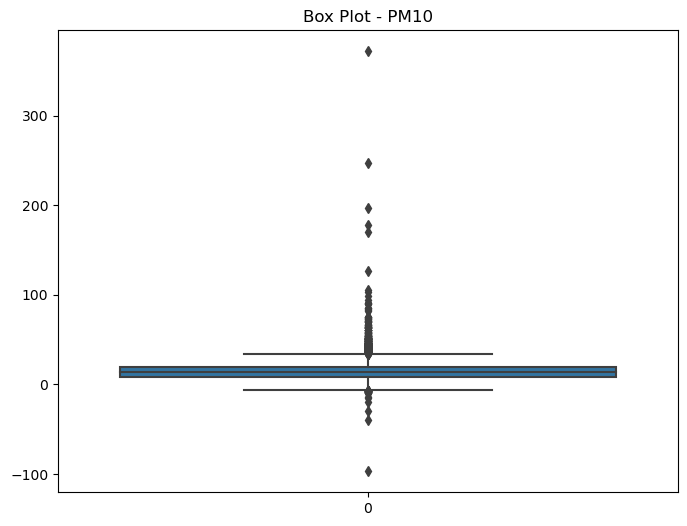

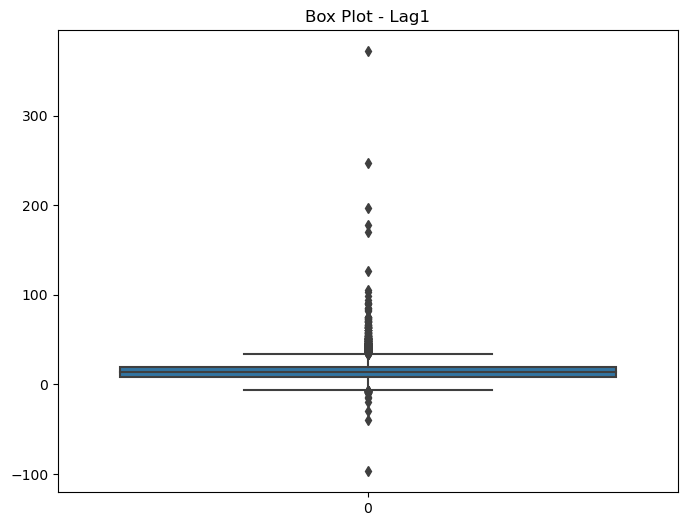

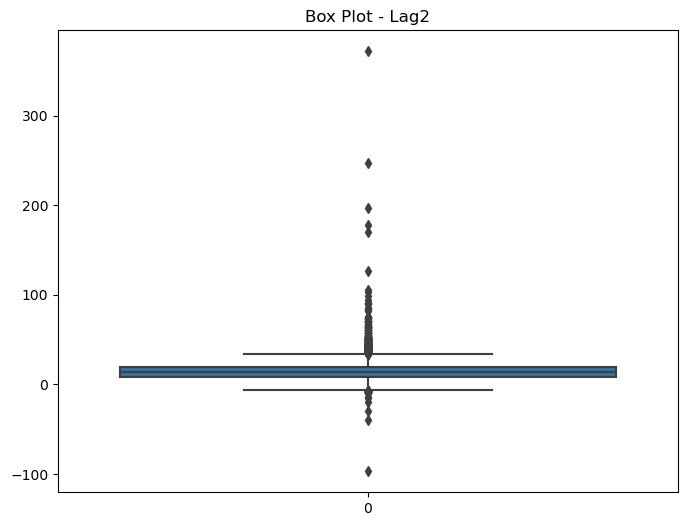

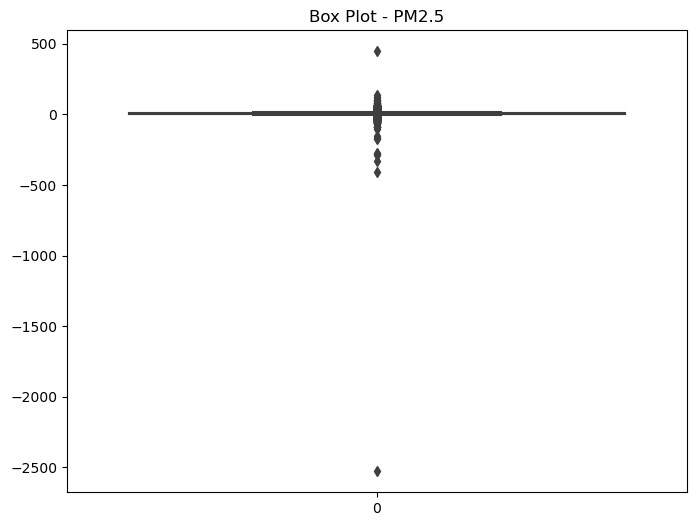

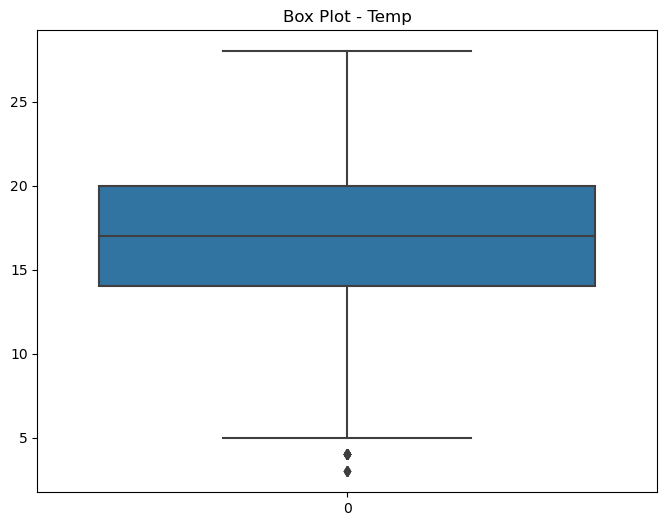

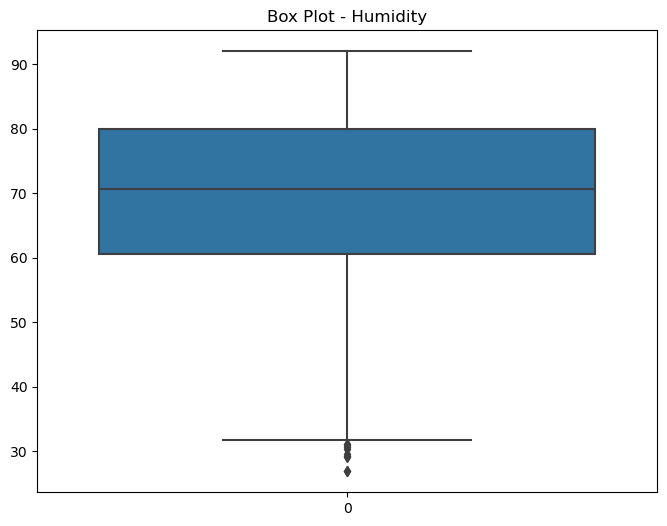

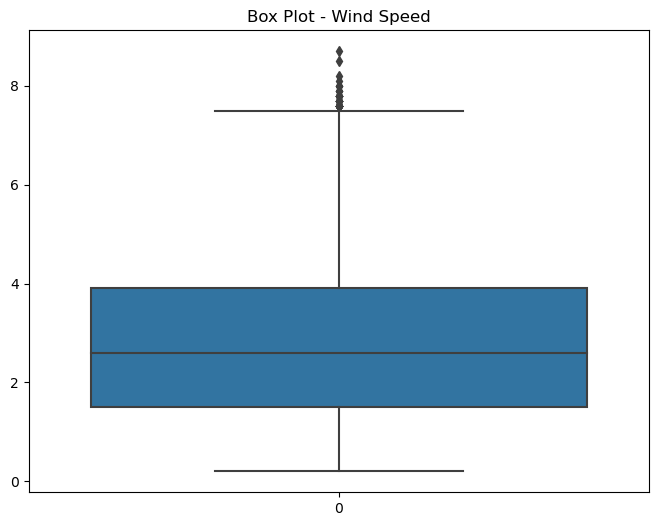

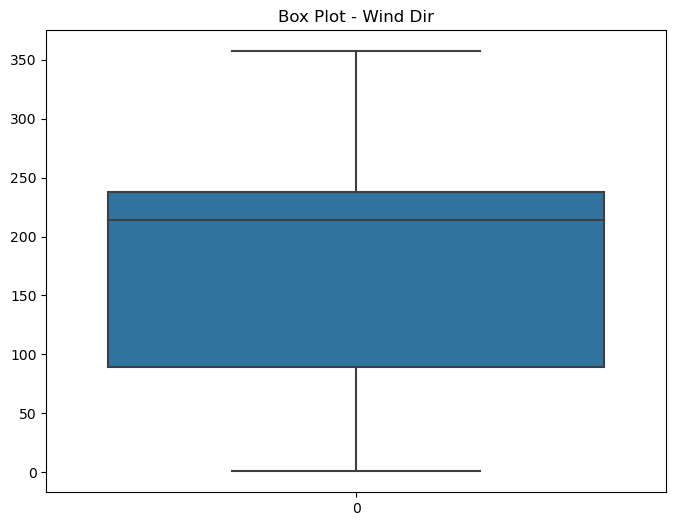

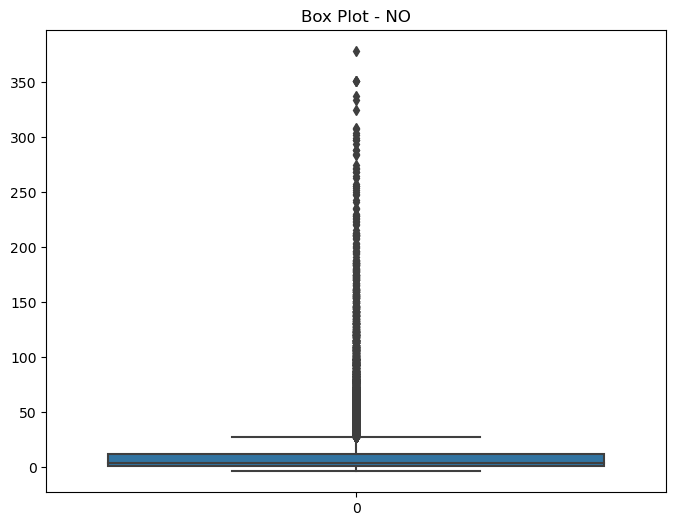

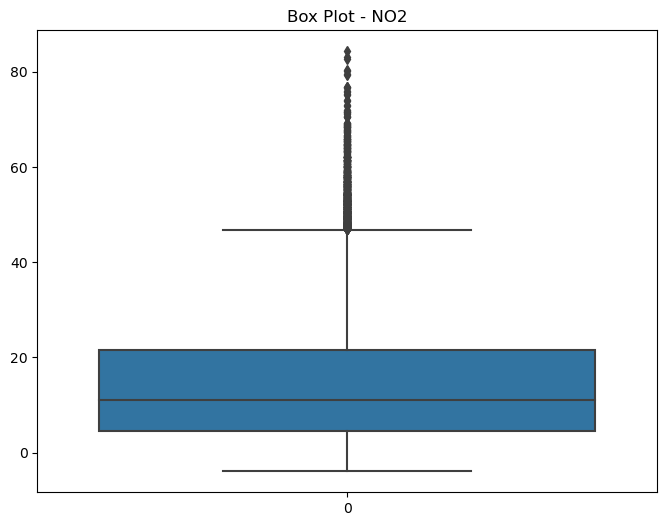

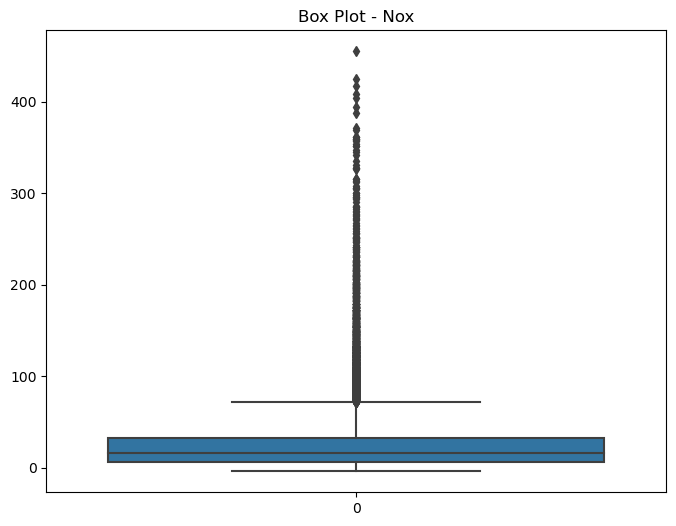

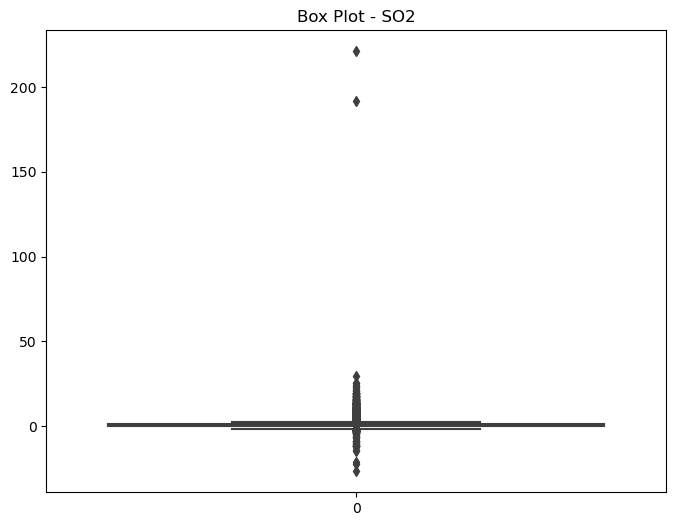

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have a pandas DataFrame named 'data' with your attribute columns

# Create a box plot for each attribute
for column in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df[column])
    plt.title(f'Box Plot - {column}')
    plt.show()


In [19]:
import pandas as pd

# Calculate summary statistics for each attribute
summary_stats = df.describe()

# Add skewness and kurtosis to the summary statistics
summary_stats.loc['skewness'] = df.skew()
summary_stats.loc['kurtosis'] = df.kurtosis()

# Transpose the summary statistics for better readability
summary_stats = summary_stats.transpose()

# Print the summary statistics
print(summary_stats)


              count        mean        std     min   25%    50%    75%    max  \
PM10        34851.0   14.436719   8.841793   -97.0   8.7   13.5   19.0  372.0   
Lag1        34851.0   14.436022   8.842058   -97.0   8.7   13.5   19.0  372.0   
Lag2        34851.0   14.435554   8.842665   -97.0   8.7   13.5   19.0  372.0   
PM2.5       33215.0    5.622165  16.565930 -2529.6   2.6    5.3    8.3  447.7   
Temp        34611.0   16.620098   3.945474     3.0  14.0   17.0   20.0   28.0   
Humidity    34612.0   69.806267  12.312313    26.9  60.6   70.7   79.9   92.0   
Wind Speed  34554.0    2.813518   1.582642     0.2   1.5    2.6    3.9    8.7   
Wind Dir    34555.0  181.226161  92.542285     1.0  89.0  214.0  238.0  357.0   
NO          34080.0   10.625822  21.579455    -3.8   1.0    4.0   11.5  378.4   
NO2         34066.0   14.717096  12.843660    -3.9   4.6   11.1   21.5   84.3   
Nox         34081.0   25.138278  31.385045    -4.1   6.1   15.7   32.4  455.1   
SO2         34586.0    0.940

Q-Q plots to compare the distribution of each attribute against a theoretical distribution (e.g., normal distribution). Q-Q plots help assess whether the data follows a particular distribution or if there are deviations.

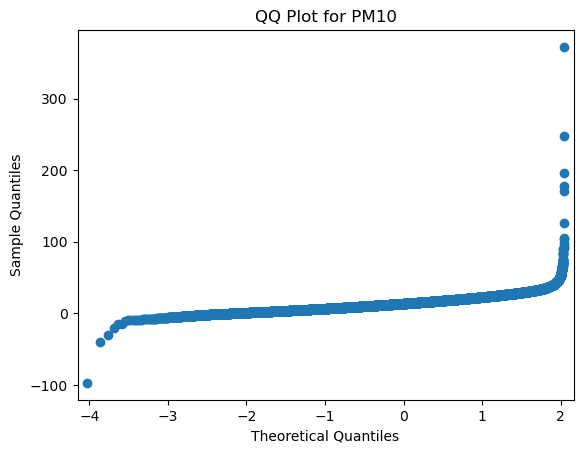

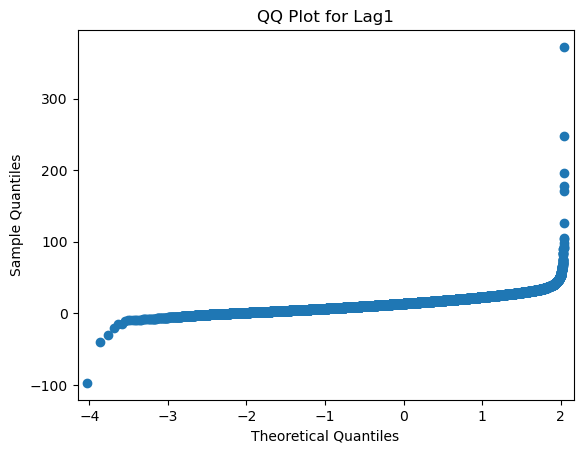

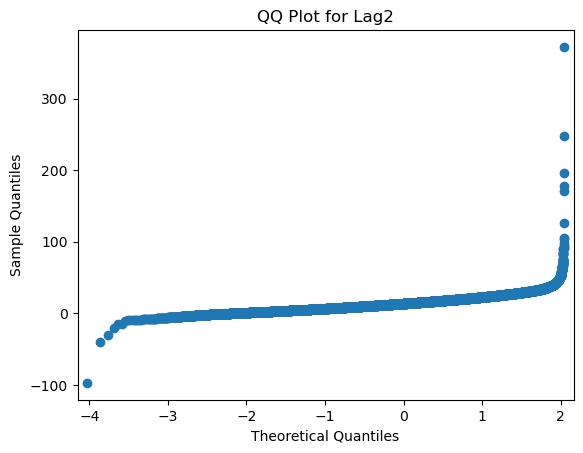

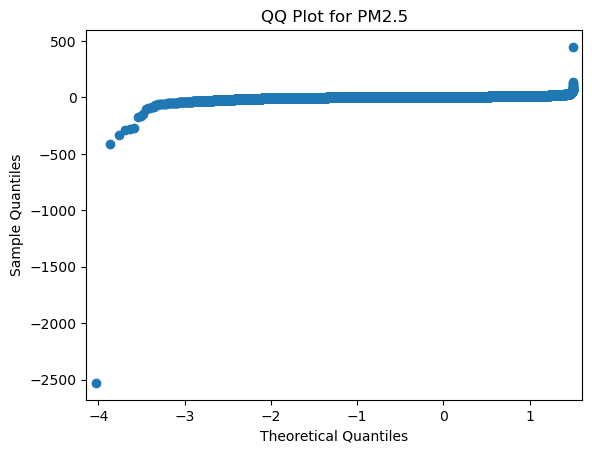

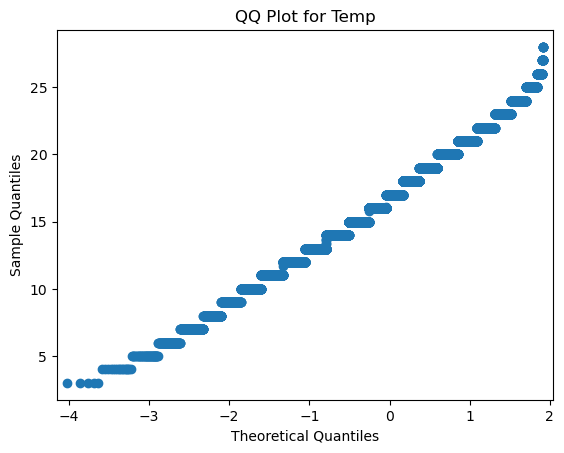

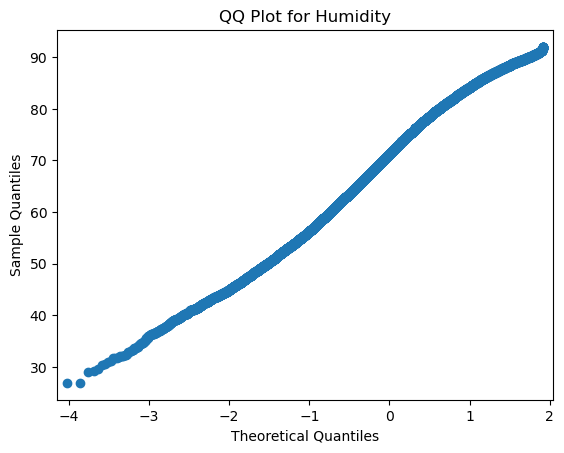

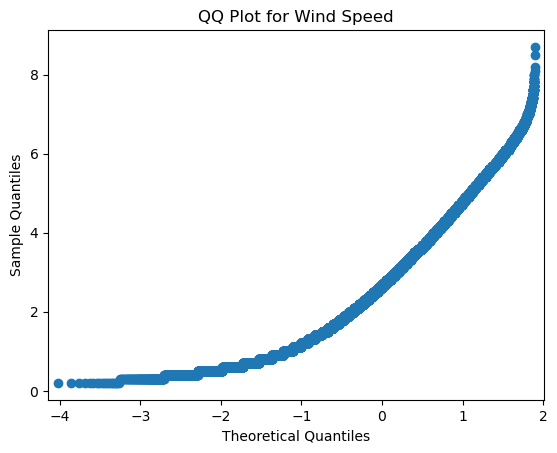

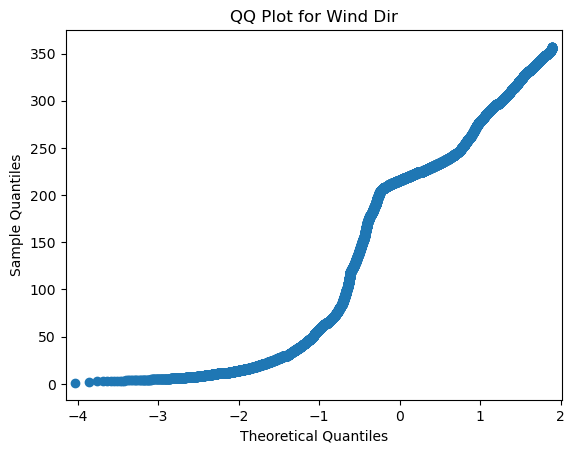

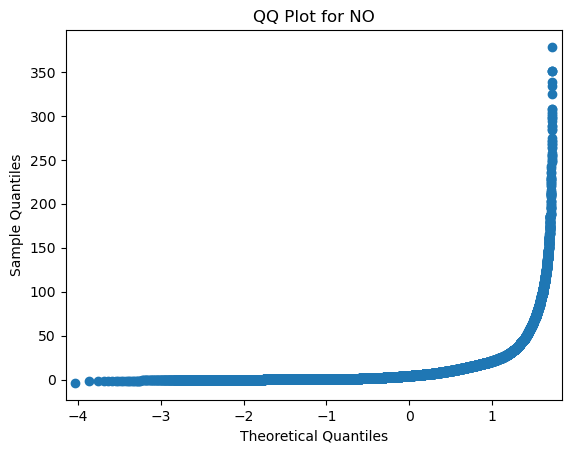

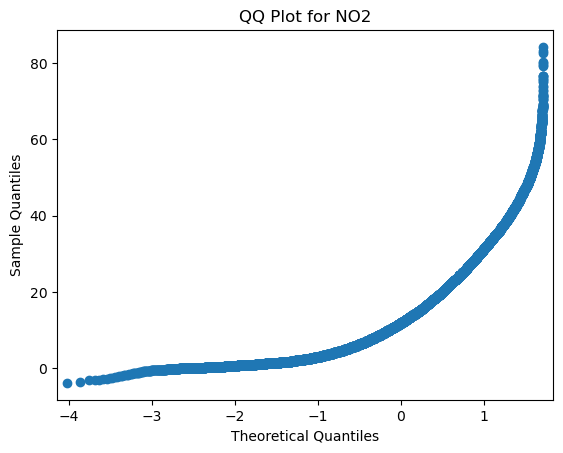

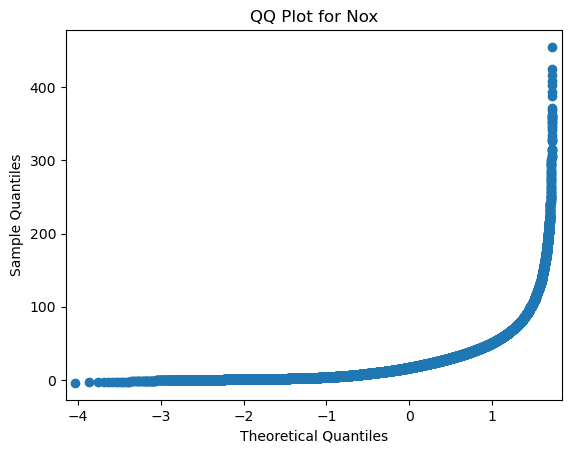

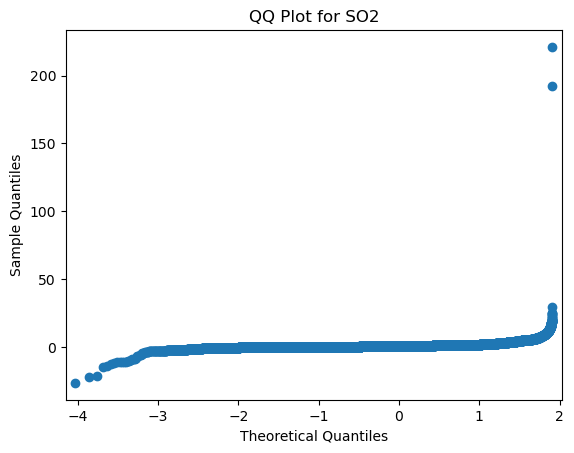

In [21]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Iterate over each attribute in the dataframe
for attribute in df.columns:
    # Create the QQ plot
    sm.qqplot(df[attribute], line='s')

    # Set plot title and labels
    plt.title('QQ Plot for {}'.format(attribute))
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Sample Quantiles')

    # Display the plot
    plt.show()


A histogram to visualize the frequency distribution of values for each attribute. The histogram will give you an overview of the shape of the distribution and the concentration of values within different ranges or bins.

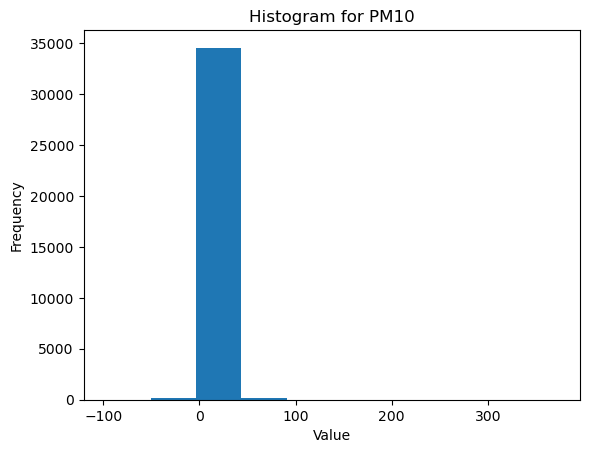

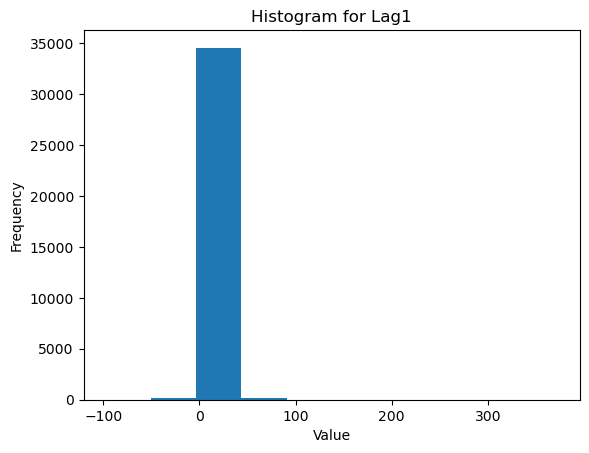

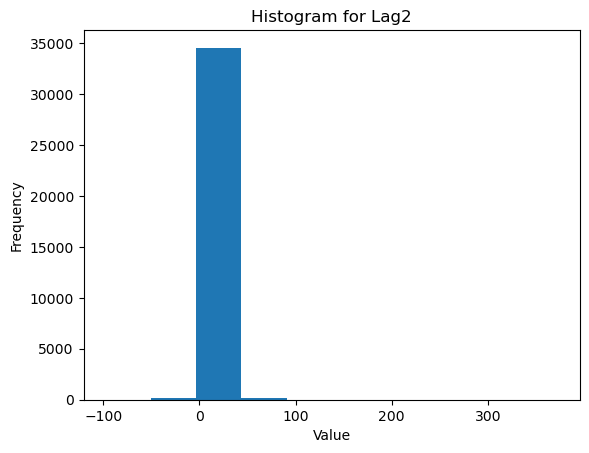

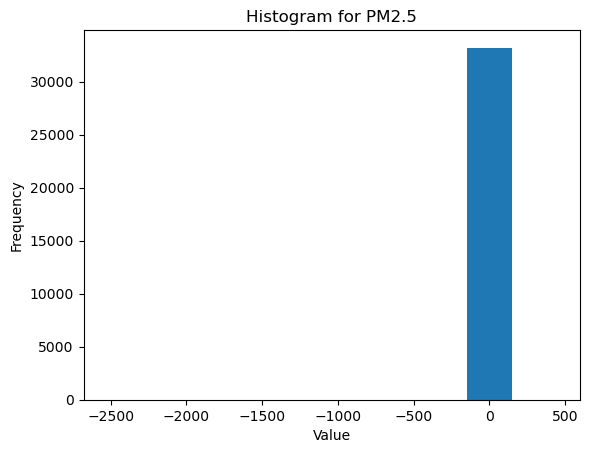

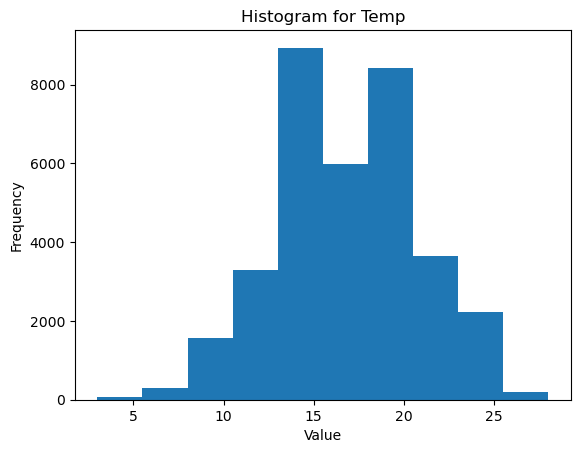

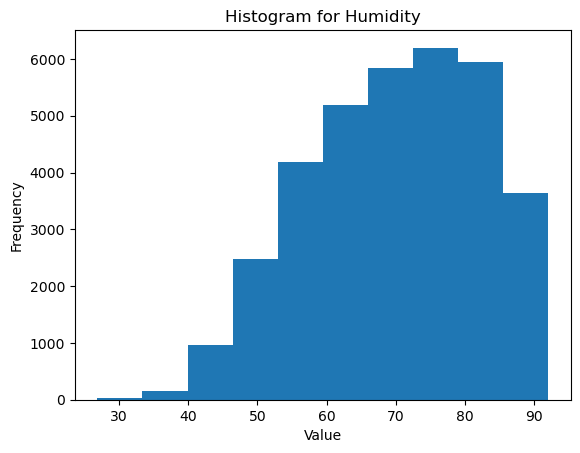

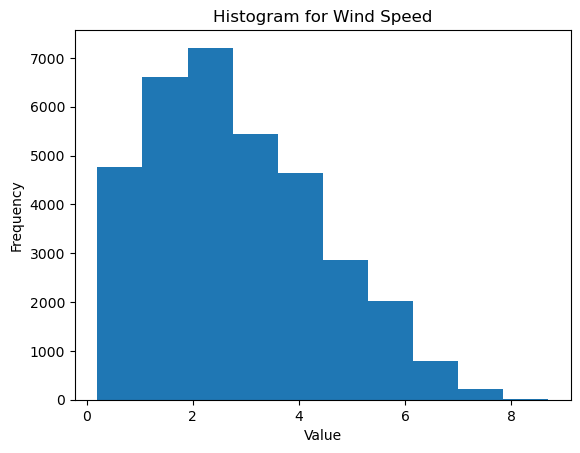

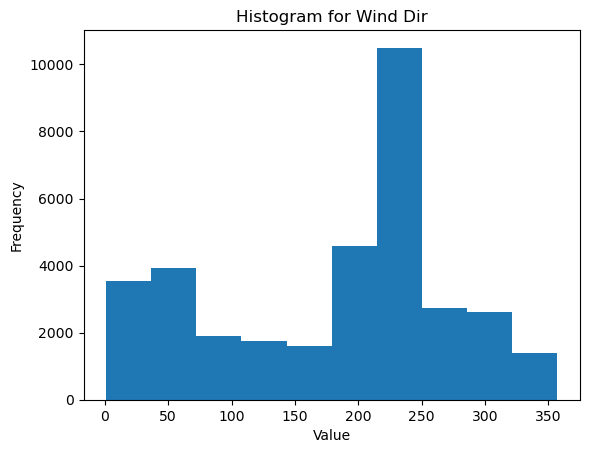

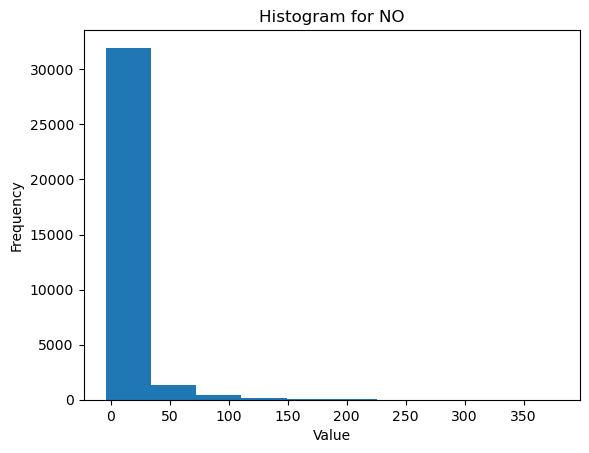

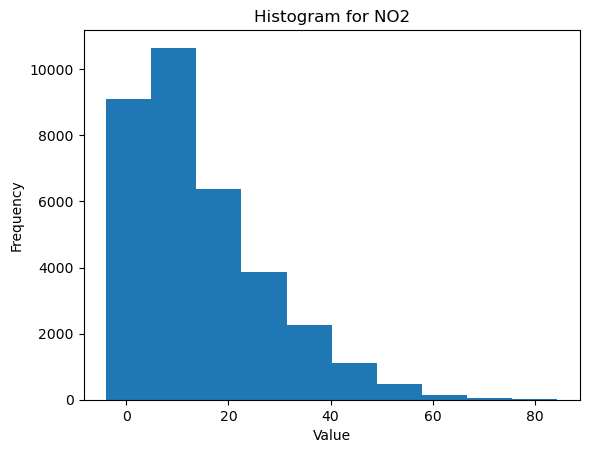

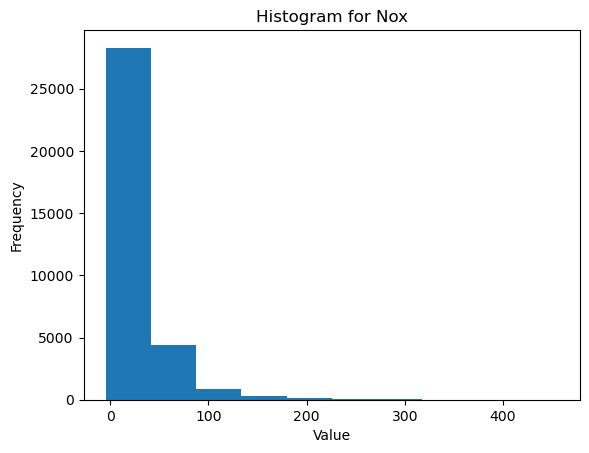

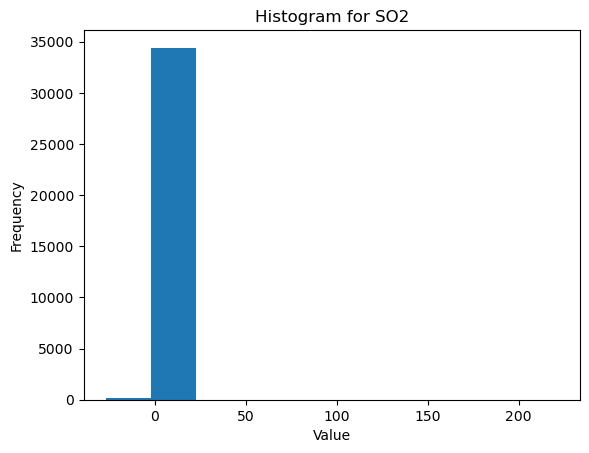

In [22]:
import matplotlib.pyplot as plt

# Iterate over each attribute in the dataframe
for attribute in df.columns:
    # Create the histogram
    plt.hist(df[attribute], bins=10)

    # Set plot title and labels
    plt.title('Histogram for {}'.format(attribute))
    plt.xlabel('Value')
    plt.ylabel('Frequency')

    # Display the plot
    plt.show()


Correlation Matrix.

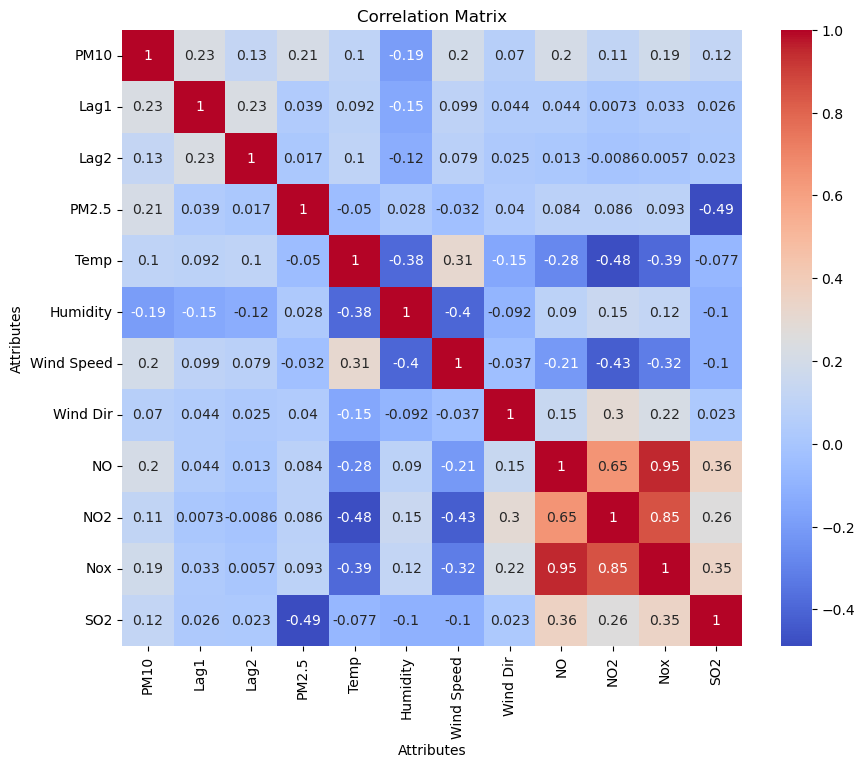

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your data is stored in a DataFrame called 'df'
correlation_matrix = df.corr()

# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

# Set plot title and labels
plt.title('Correlation Matrix')
plt.xlabel('Attributes')
plt.ylabel('Attributes')

# Display the plot
plt.show()


In [24]:
import pandas as pd

# Assuming your data is stored in a DataFrame called 'df'
correlation_table = df.corr()

# Display the correlation table
print(correlation_table)


                PM10      Lag1      Lag2     PM2.5      Temp  Humidity  \
PM10        1.000000  0.230352  0.126664  0.211199  0.099691 -0.193350   
Lag1        0.230352  1.000000  0.230161  0.038787  0.091991 -0.149574   
Lag2        0.126664  0.230161  1.000000  0.017025  0.102799 -0.122211   
PM2.5       0.211199  0.038787  0.017025  1.000000 -0.049646  0.027892   
Temp        0.099691  0.091991  0.102799 -0.049646  1.000000 -0.384905   
Humidity   -0.193350 -0.149574 -0.122211  0.027892 -0.384905  1.000000   
Wind Speed  0.195916  0.098958  0.078625 -0.031765  0.313137 -0.395944   
Wind Dir    0.069870  0.044012  0.024764  0.040060 -0.152695 -0.091866   
NO          0.204253  0.044295  0.013069  0.083727 -0.276516  0.089782   
NO2         0.113713  0.007283 -0.008561  0.086495 -0.476594  0.148512   
Nox         0.185895  0.033317  0.005727  0.092832 -0.386347  0.122366   
SO2         0.117626  0.026011  0.022521 -0.487857 -0.076914 -0.104782   

            Wind Speed  Wind Dir     

In [28]:
import pandas as pd

# Assuming your data is stored in a DataFrame called 'df'
missing_values_comparison = pd.DataFrame({'PM10': [df['PM10'].isnull().sum()], 'PM2.5': [df['PM2.5'].isnull().sum()]})

# Display the comparison of missing values
print(missing_values_comparison)


   PM10  PM2.5
0   734   2370


Dropping P2.5. from the dataset.

In [29]:
# Assuming your DataFrame is called 'df'
df = df.drop('PM2.5', axis=1)


In [30]:
import pandas as pd

# Calculate the IQR for each attribute
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1

# Define the threshold for outliers
threshold = 1.5
lower_bound = q1 - threshold * iqr
upper_bound = q3 + threshold * iqr

# Identify outliers for each attribute
outliers = ((df < lower_bound) | (df > upper_bound)).any(axis=1)

# Examine the rows containing outliers
outlier_rows = df[outliers]

# Print the outlier rows
print(outlier_rows)


       PM10  Lag1  Lag2  Temp  Humidity  Wind Speed  Wind Dir    NO   NO2  \
82      1.2  10.1  18.3  19.0      87.2         2.4     309.0  20.1  39.1   
88     35.1   6.1  24.8  21.0      52.8         4.4     249.0   9.6  13.2   
107    26.4  10.7  16.5  20.0      46.2         3.7     261.0  12.4  12.0   
109    36.2  17.7   7.9  20.0      49.5         5.2     246.0  16.4  12.6   
112    27.2  35.1   6.1  20.0      46.4         4.7     251.0  12.9  10.8   
...     ...   ...   ...   ...       ...         ...       ...   ...   ...   
35473  13.2  23.5  11.5   NaN       NaN         NaN       NaN  13.8   8.5   
35474  19.3   9.1  17.2   NaN       NaN         NaN       NaN  12.6  10.6   
35475   8.6  11.5  11.5   NaN       NaN         NaN       NaN   6.6   8.4   
35521   5.1  21.4  13.2   NaN       NaN         NaN       NaN   7.4   6.3   
35526   4.0  12.3  18.3   NaN       NaN         NaN       NaN   7.8   5.9   

        Nox   SO2  
82     59.2   2.7  
88     22.8   1.5  
107    24.4   2

In [31]:
import numpy as np

# Apply logarithmic transformation to 'PM10'
df['PM10_transformed'] = np.log(df['PM10'])

# Check the updated summary statistics
summary_stats_transformed = df['PM10_transformed'].describe()
print(summary_stats_transformed)


count    3.437300e+04
mean             -inf
std               NaN
min              -inf
25%      2.186051e+00
50%      2.610070e+00
75%      2.949688e+00
max      5.918894e+00
Name: PM10_transformed, dtype: float64


/Users/natashasmith/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/natashasmith/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [32]:
df.drop('PM10_transformed', axis=1, inplace=True)


In [36]:
import numpy as np
from scipy.stats import mstats

# Define the quantile limits for Winsorization
quantile_limits = [0.05, 0.05]  # 5% quantile on each tail

# Iterate over each variable in the DataFrame
for column in df.columns:
    # Winsorize the variable using the defined quantile limits
    winsorized_values = mstats.winsorize(df[column], limits=quantile_limits)
    
    # Replace the original values with the winsorized values
    df[column] = winsorized_values


# Calculate summary statistics after Winsorization
summary_stats = df.describe()

# Display the summary statistics
print(summary_stats)



               PM10          Lag1          Lag2          Temp      Humidity  \
count  35585.000000  35585.000000  35585.000000  35585.000000  35585.000000   
mean      14.666739     14.666056     14.665598     16.865567     70.529102   
std        7.716710      7.717029      7.717722      3.887161     12.100702   
min        2.900000      2.900000      2.900000     10.000000     48.700000   
25%        8.800000      8.800000      8.800000     14.000000     61.000000   
50%       13.700000     13.700000     13.700000     17.000000     71.300000   
75%       19.500000     19.500000     19.500000     20.000000     80.700000   
max       31.600000     31.600000     31.600000     24.000000     89.400000   

         Wind Speed      Wind Dir            NO           NO2           Nox  \
count  35585.000000  35585.000000  35585.000000  35585.000000  35585.000000   
mean       2.916569    185.865842     14.853200     16.475574     30.736286   
std        1.639329     93.781681     28.269037    

/Users/natashasmith/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:4650: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/Users/natashasmith/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:4650: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/Users/natashasmith/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:4650: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/Users/natashasmith/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:4650: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/Users/natashasmith/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/function_base.py:4650: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
/Users/natashasmith/opt/anaconda3/lib/python3.9/site-pa

In [37]:
# Check for missing values in the DataFrame
missing_values = df.isnull().sum()

# Display the count of missing values for each column
print(missing_values)


PM10          0
Lag1          0
Lag2          0
Temp          0
Humidity      0
Wind Speed    0
Wind Dir      0
NO            0
NO2           0
Nox           0
SO2           0
dtype: int64


In [38]:
import pandas as pd

# Assuming your data is stored in a DataFrame called 'df'
correlation_table = df.corr()

# Display the correlation table
print(correlation_table)

                PM10      Lag1      Lag2      Temp  Humidity  Wind Speed  \
PM10        1.000000  0.257290  0.149485  0.087713 -0.187360    0.204468   
Lag1        0.257290  1.000000  0.257047  0.059560 -0.152834    0.087106   
Lag2        0.149485  0.257047  1.000000  0.067164 -0.129600    0.064728   
Temp        0.087713  0.059560  0.067164  1.000000 -0.268908    0.378343   
Humidity   -0.187360 -0.152834 -0.129600 -0.268908  1.000000   -0.275372   
Wind Speed  0.204468  0.087106  0.064728  0.378343 -0.275372    1.000000   
Wind Dir    0.072175  0.031959  0.016249 -0.060594 -0.023639    0.067869   
NO          0.166732  0.045829  0.027018 -0.119186  0.159130   -0.048791   
NO2         0.119257  0.017066  0.006924 -0.347925  0.188272   -0.279116   
Nox         0.158688  0.037447  0.020576 -0.218179  0.177772   -0.142777   
SO2         0.152118  0.052158  0.046534 -0.105009 -0.046595   -0.134206   

            Wind Dir        NO       NO2       Nox       SO2  
PM10        0.072175  0.

NOX, NO and NO2 are highly correlated; need to decide which one best to keep. My opinion, it is NO  (correlation with PO10 = 16.6). 

Correlation Plot.

In [44]:
# Drop the 'NOx' and 'NO2' variables
df = df.drop(['Nox', 'NO2'], axis=1)

In [46]:
import pandas as pd

# Assuming your data is stored in a DataFrame called 'df'
correlation_table = df.corr()

# Display the correlation table
print(correlation_table)

                PM10      Lag1      Lag2      Temp  Humidity  Wind Speed  \
PM10        1.000000  0.257290  0.149485  0.087713 -0.187360    0.204468   
Lag1        0.257290  1.000000  0.257047  0.059560 -0.152834    0.087106   
Lag2        0.149485  0.257047  1.000000  0.067164 -0.129600    0.064728   
Temp        0.087713  0.059560  0.067164  1.000000 -0.268908    0.378343   
Humidity   -0.187360 -0.152834 -0.129600 -0.268908  1.000000   -0.275372   
Wind Speed  0.204468  0.087106  0.064728  0.378343 -0.275372    1.000000   
Wind Dir    0.072175  0.031959  0.016249 -0.060594 -0.023639    0.067869   
NO          0.166732  0.045829  0.027018 -0.119186  0.159130   -0.048791   
SO2         0.152118  0.052158  0.046534 -0.105009 -0.046595   -0.134206   

            Wind Dir        NO       SO2  
PM10        0.072175  0.166732  0.152118  
Lag1        0.031959  0.045829  0.052158  
Lag2        0.016249  0.027018  0.046534  
Temp       -0.060594 -0.119186 -0.105009  
Humidity   -0.023639  0.

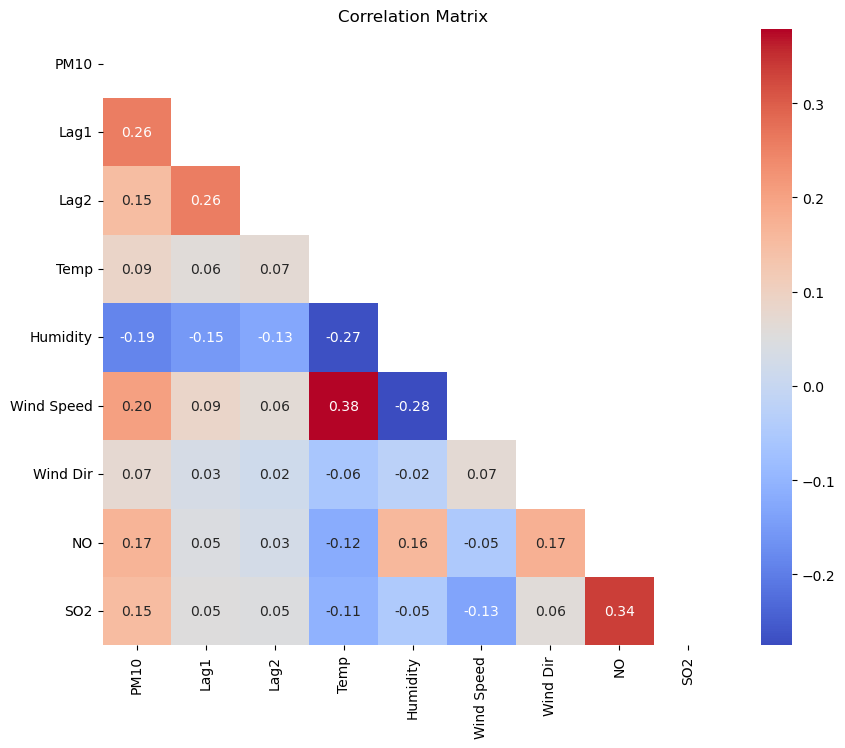

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix = df.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create the correlation heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, ax=ax)

# Set plot title
plt.title("Correlation Matrix")

# Show the plot
plt.show()


In [48]:
import matplotlib.pyplot as plt

# Assuming your data is stored in a DataFrame called 'df'
timestamps = df['Timestamp']  # Replace 'Timestamp' with the actual column name
pm_concentration = df['PM10']  # Replace 'PM10' with the actual column name

# Plot the PM concentration over time
plt.figure(figsize=(12, 6))
plt.plot(timestamps, pm_concentration)
plt.title('Variation of PM Concentration')
plt.xlabel('Timestamp')
plt.ylabel('PM Concentration')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


KeyError: 'Timestamp'

In [49]:
import pandas as pd

# Specify the file path
file_path = "Desktop/data.xlsx"

# Read the .xlsx file
df = pd.read_excel(file_path)

# Assuming your timestamp column is called 'Timestamp' and is stored as a separate column in your dataset
timestamp_data = pd.to_datetime(df['Timestamp'])  # Replace 'Timestamp' with the actual column name

# Add the timestamp data as a new column in your DataFrame
df['Timestamp'] = timestamp_data

# Print the updated DataFrame
print(df)


                Timestamp  PM10  Lag1  Lag2  PM2.5  Temp  Humidity  \
0     2018-12-01 00:00:00  15.8  10.2  18.6    6.5  18.0      76.1   
1     2018-12-01 01:00:00  18.1   9.1  21.4   25.6  18.0      79.1   
2     2018-12-01 02:00:00  15.9   8.6  17.8    1.7  18.0      76.4   
3     2018-12-01 03:00:00  16.1   9.9  17.5    1.7  18.0      75.1   
4     2018-12-01 04:00:00  18.5   7.1  21.7   -5.7  18.0      79.2   
...                   ...   ...   ...   ...    ...   ...       ...   
35580 2022-12-30 20:00:00  20.7  16.2  15.9    4.3   NaN       NaN   
35581 2022-12-30 21:00:00  10.9  17.0  10.3    4.6   NaN       NaN   
35582 2022-12-30 22:00:00  20.8  14.8   9.6    5.6   NaN       NaN   
35583 2022-12-30 23:00:00  16.1   8.4   5.3    6.8   NaN       NaN   
35584 2022-12-31 00:00:00  24.7  19.0  10.5    8.8   NaN       NaN   

       Wind Speed  Wind Dir   NO   NO2   Nox  SO2  
0             5.4      52.0  0.2   0.8   1.0  1.7  
1             4.8      60.0 -0.1   0.6   0.5  NaN  
2  

In [50]:
import pandas as pd

# Specify the file path
file_path = "Desktop/data.xlsx"

# Read the .xlsx file
df = pd.read_excel(file_path)

# Assuming your timestamp column is called 'Timestamp' and is stored as a separate column in your dataset
timestamp_data = pd.to_datetime(df['Timestamp'])  # Replace 'Timestamp' with the actual column name

# Fill 'NaN' values in the timestamp column with a specific value or strategy
timestamp_data = timestamp_data.fillna(method='ffill')  # Replace 'ffill' with the desired strategy

# Add the timestamp data as a new column in your DataFrame
df['Timestamp'] = timestamp_data

# Print the updated DataFrame
print(df)


                Timestamp  PM10  Lag1  Lag2  PM2.5  Temp  Humidity  \
0     2018-12-01 00:00:00  15.8  10.2  18.6    6.5  18.0      76.1   
1     2018-12-01 01:00:00  18.1   9.1  21.4   25.6  18.0      79.1   
2     2018-12-01 02:00:00  15.9   8.6  17.8    1.7  18.0      76.4   
3     2018-12-01 03:00:00  16.1   9.9  17.5    1.7  18.0      75.1   
4     2018-12-01 04:00:00  18.5   7.1  21.7   -5.7  18.0      79.2   
...                   ...   ...   ...   ...    ...   ...       ...   
35580 2022-12-30 20:00:00  20.7  16.2  15.9    4.3   NaN       NaN   
35581 2022-12-30 21:00:00  10.9  17.0  10.3    4.6   NaN       NaN   
35582 2022-12-30 22:00:00  20.8  14.8   9.6    5.6   NaN       NaN   
35583 2022-12-30 23:00:00  16.1   8.4   5.3    6.8   NaN       NaN   
35584 2022-12-31 00:00:00  24.7  19.0  10.5    8.8   NaN       NaN   

       Wind Speed  Wind Dir   NO   NO2   Nox  SO2  
0             5.4      52.0  0.2   0.8   1.0  1.7  
1             4.8      60.0 -0.1   0.6   0.5  NaN  
2  

In [51]:
import pandas as pd

# Assuming your data is stored in a DataFrame called 'df'

# Forward fill (ffill)
df_ffill = df.ffill()

# Backward fill (bfill)
df_bfill = df.bfill()

# Compare the results
# Calculate the number of missing values in each DataFrame
missing_values_ffill = df_ffill.isnull().sum()
missing_values_bfill = df_bfill.isnull().sum()

# Display the comparison of missing values
print("Missing values with forward fill:")
print(missing_values_ffill)
print("\nMissing values with backward fill:")
print(missing_values_bfill)


Missing values with forward fill:
Timestamp     0
PM10          0
Lag1          0
Lag2          0
PM2.5         0
Temp          0
Humidity      0
Wind Speed    0
Wind Dir      0
NO            0
NO2           0
Nox           0
SO2           0
dtype: int64

Missing values with backward fill:
Timestamp     0
PM10          0
Lag1          0
Lag2          0
PM2.5         0
Temp          5
Humidity      5
Wind Speed    5
Wind Dir      5
NO            0
NO2           0
Nox           0
SO2           0
dtype: int64


In [57]:
import pandas as pd

# Specify the file path
file_path = "Desktop/data.xlsx"

# Read the .xlsx file
df = pd.read_excel(file_path)

# Drop the 'PM2.5' variable
df = df.drop('PM2.5', axis=1)

# Save the modified dataset on the desktop
output_file_path = "Desktop/mod_data.xlsx"
df.to_excel(output_file_path, index=False)



               PM10          Lag1          Lag2          Temp      Humidity  \
count  34851.000000  34851.000000  34851.000000  34611.000000  34612.000000   
mean      14.436719     14.436022     14.435554     16.620098     69.806267   
std        8.841793      8.842058      8.842665      3.945474     12.312313   
min      -97.000000    -97.000000    -97.000000      3.000000     26.900000   
25%        8.700000      8.700000      8.700000     14.000000     60.600000   
50%       13.500000     13.500000     13.500000     17.000000     70.700000   
75%       19.000000     19.000000     19.000000     20.000000     79.900000   
max      372.000000    372.000000    372.000000     28.000000     92.000000   

         Wind Speed      Wind Dir            NO           NO2           Nox  \
count  34554.000000  34555.000000  34080.000000  34066.000000  34081.000000   
mean       2.813518    181.226161     10.625822     14.717096     25.138278   
std        1.582642     92.542285     21.579455    

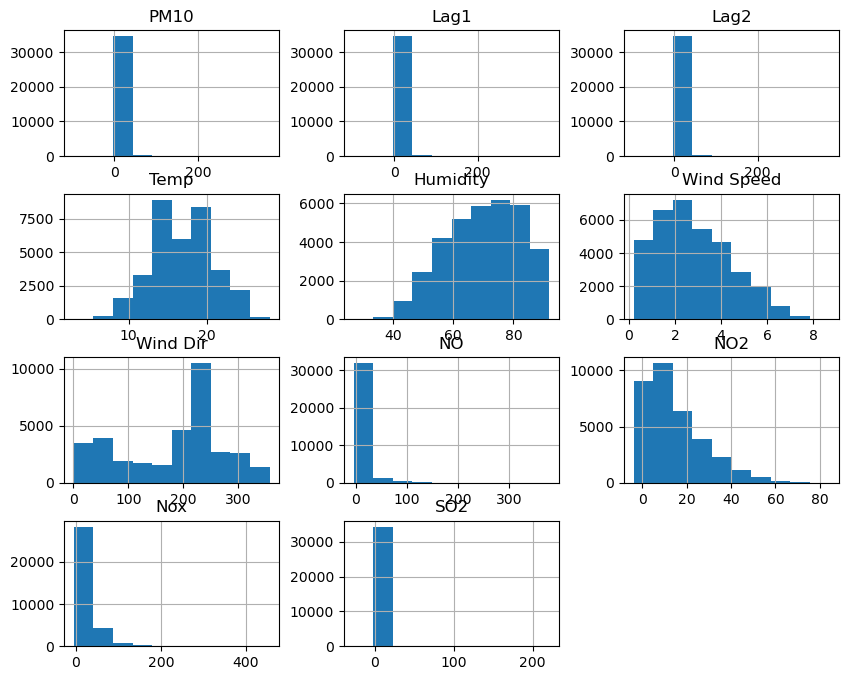

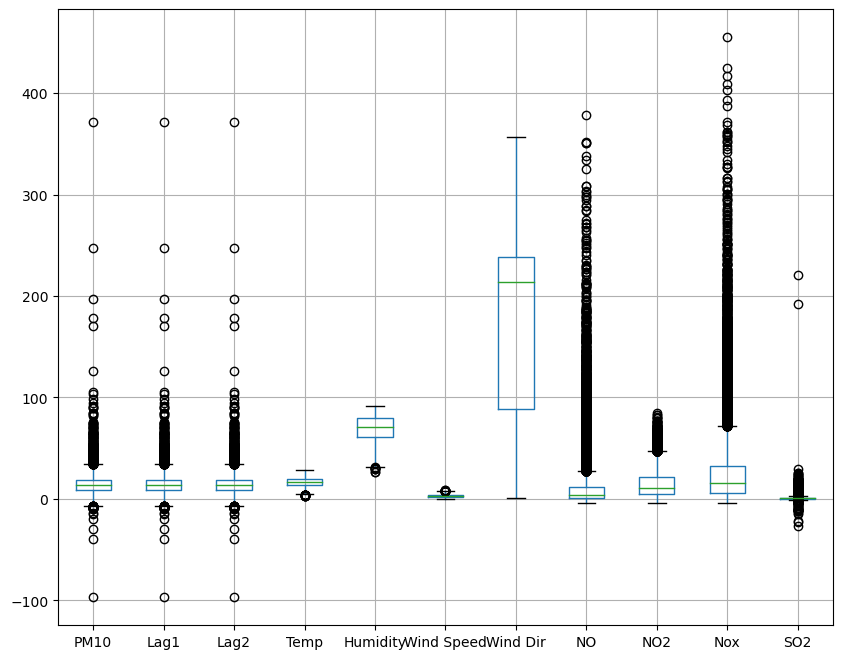

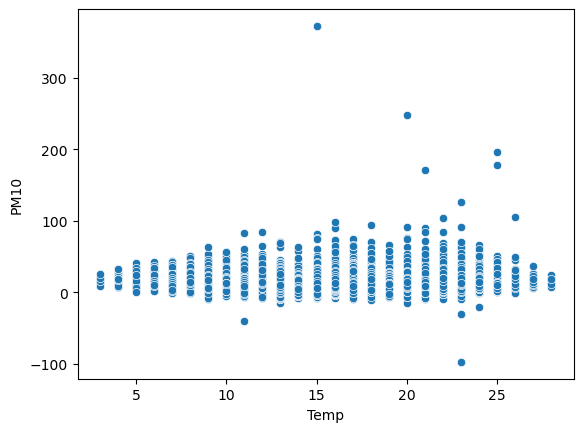

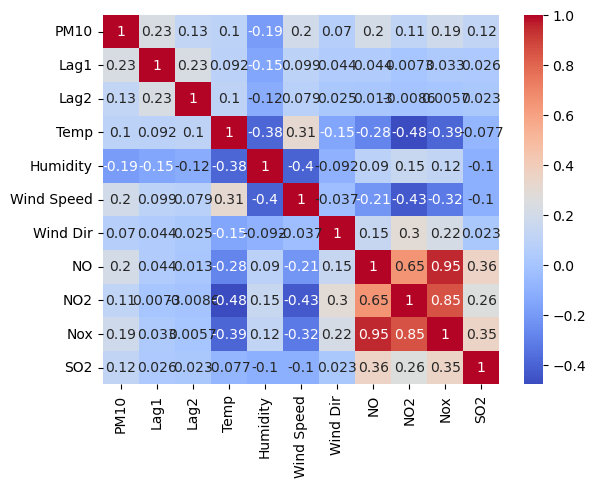

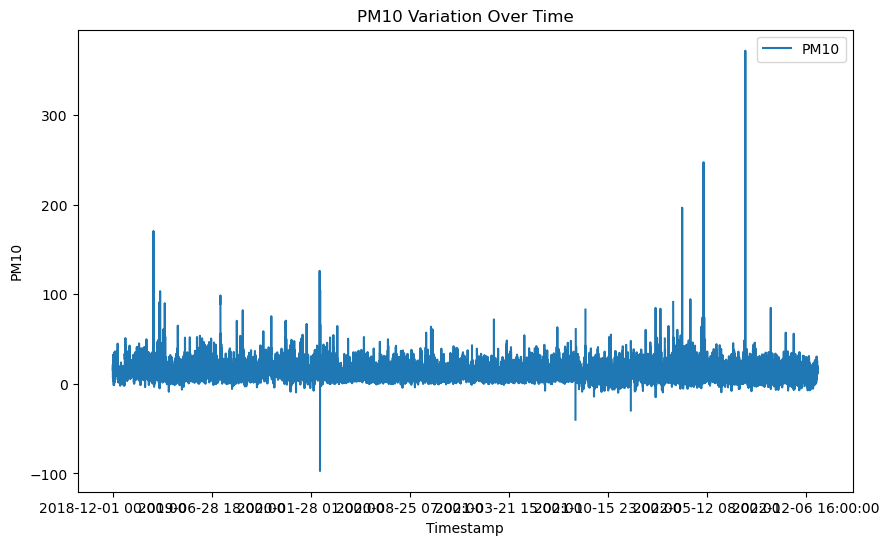

Timestamp        0
PM10           734
Lag1           734
Lag2           734
Temp           974
Humidity       973
Wind Speed    1031
Wind Dir      1030
NO            1505
NO2           1519
Nox           1504
SO2            999
dtype: int64


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Specify the file path
file_path = "Desktop/mod_data.xlsx"

# Read the .xlsx file
df = pd.read_excel(file_path)


# Summary Statistics
summary_stats = df.describe()
print(summary_stats)

# Histograms
df.hist(figsize=(10, 8))
plt.show()

# Box Plots
df.boxplot(figsize=(10, 8))
plt.show()

# Scatter Plot
sns.scatterplot(data=df, x='Temp', y='PM10')
plt.show()

# Heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


# Line Plot
df.plot(x='Timestamp', y='PM10', figsize=(10, 6))
plt.xlabel('Timestamp')
plt.ylabel('PM10')
plt.title('PM10 Variation Over Time')
plt.show()

# Missing Data Analysis
missing_values = df.isnull().sum()
print(missing_values)

# Feature Importance (example using Random Forest Classifier)
from sklearn.ensemble import RandomForestClassifier

X = df.drop('PM10', axis=1)
y = df['PM10']

rf = RandomForestClassifier()


In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

# Specify the file path
file_path = "Desktop/mod_data.xlsx"

# Read the .xlsx file
df = pd.read_excel(file_path)

# Split the data into features (X) and target variable (y)
X = df[['Lag1', 'Lag2', 'Temp', 'Humidity', 'Wind Speed', 'Wind Dir', 'NO', 'SO2']]
y = df['PM10']

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Scale the input features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print('RMSE:', rmse)
print('MAE:', mae)
print('R2:', r2)



ValueError: Input contains NaN, infinity or a value too large for dtype('float64').